## Бізнес-контекст
Компанія HealthRisk Analytics продовжує покращувати модель прогнозування медичних ризиків.
Команда розробників хоче зрозуміти, як різні функції активації та прийоми регуляризації (Dropout, Batch Normalization) впливають на стабільність і якість навчання моделі. Ваше завдання — провести серію експериментів і порівняти результати.

## Завдання 1
 - Дослідіть вплив функцій активації на результати моделі.
 - Згенеруйте синтетичні дані для регресії за допомогою функції make_regression (2000 рядків, 10 ознак, noise=10, random_state=42).
 - Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
 - Послідовно застосуйте різні функції активації: ReLU, Tanh, LeakyReLU, Swish.
 - Для кожної активації розрахуйте MAE і R² на тестовій вибірці.
 - Оформіть результати в таблиці:

| Активація | MAE | R² |
| :--- | :---: | :---: |
| ReLU | ... | ... |
| Tanh | ... | ... |
| LeakyReLU | ... | ... |
| Swish | ... | ... |

In [67]:
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=2000, n_features=10, noise=10, random_state=42)
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

import torch
xtrain = torch.tensor(xtrain, dtype=torch.float32)
xtest = torch.tensor(xtest, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.float32).reshape(-1,1) * 0.1
ytest = torch.tensor(ytest, dtype=torch.float32).reshape(-1,1) * 0.1

In [68]:
import torch.nn as nn

activators = {
    "Sigmoid": nn.Sigmoid(),
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "LeakyReLU": nn.LeakyReLU(),
    "SiLU": nn.SiLU(),
    "Swish": nn.SiLU(),
}

In [69]:
class Mlp(nn.Module):
    def __init__(self,
                input_size=10,
                hidden_size=32,
                output_size=1,
                activation="ReLU"
    ): 
        super(Mlp, self).__init__()
        self.activation = activators.get(activation, None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            self.activation,
            nn.Linear(hidden_size, output_size)
        )
    def forward(self, x) :
        return self.layers(x)

In [70]:
def train_model(model, X, y, epochs=1000, lr=0.01) :
    criterion = nn.functional.mse_loss
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = [*range(epochs)]
    for epoch in range(epochs) : 
        output = model(X)
        loss = criterion(output, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses[epoch] = loss.item()
    return losses

In [71]:
mlps = { k: Mlp(activation=k) for k in activators.keys() }
#mlps

In [72]:
losses = {}
predictions = {}
for k, mlp in mlps.items():
    losses[k] = train_model(mlp, xtrain, ytrain)
    with torch.no_grad():
        predictions[k] = mlp(xtest)
        
print(*zip(*(predictions[k][:5] for k in mlps.keys()), ytest[:5]), sep='\n')

(tensor([0.1029]), tensor([-0.3033]), tensor([0.0850]), tensor([0.2820]), tensor([0.2410]), tensor([0.0402]), tensor([-0.7586]))
(tensor([-8.7875]), tensor([-8.0449]), tensor([-8.0933]), tensor([-8.1402]), tensor([-7.9414]), tensor([-8.2473]), tensor([-7.0909]))
(tensor([1.7631]), tensor([1.9536]), tensor([1.2814]), tensor([1.7386]), tensor([1.6340]), tensor([1.6024]), tensor([2.2073]))
(tensor([14.0519]), tensor([12.3501]), tensor([12.7985]), tensor([12.7246]), tensor([12.7159]), tensor([12.5917]), tensor([13.8763]))
(tensor([-2.1243]), tensor([-1.1878]), tensor([-1.8948]), tensor([-1.2946]), tensor([-1.8498]), tensor([-2.2065]), tensor([-0.7247]))


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Перетворюємо ytest у формат numpy масиву та згладжуємо
y_true = ytest.detach().cpu().numpy().flatten()

results = []

# Перебираємо активації, які є у вашому словнику mlps
for k in mlps.keys():
    # Отримуємо прогноз моделі, перетворюємо в numpy та згладжуємо
    y_pred = predictions[k].detach().cpu().numpy().flatten()
    
    # Рахуємо метрики
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Додаємо в список результатів
    results.append({
        "Активація": k,
        "MAE": round(mae, 4),
        "R²": round(r2, 4)
    })

# Створюємо датафрейм та виводимо у форматі Markdown
df_results = pd.DataFrame(results)
print(df_results.to_markdown(index=False))

In [78]:
from IPython.display import Markdown as md
import sklearn.metrics as sm

md("\n".join((
    "|Активація|MAE|R²|",
    "|-|-|-|",
    *(f"|{k}|{sm.mean_absolute_error(ytest, v):.4f}|{sm.r2_score(ytest, v):.4f}|" for k, v in predictions.items())
)))

|Активація|MAE|R²|
|-|-|-|
|Sigmoid|1.3158|0.9884|
|ReLU|0.8492|0.9970|
|Tanh|0.8794|0.9963|
|LeakyReLU|0.8514|0.9968|
|SiLU|0.8369|0.9971|
|Swish|0.8298|0.9971|

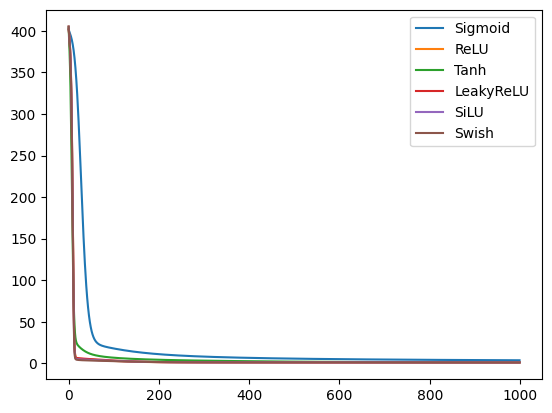

In [79]:
import matplotlib.pyplot as plt
_, ax = plt.subplots()
for k, v in losses.items():
    ax.plot(v, label=k)
ax.legend()
plt.show()